# B.2

In [1]:
import sympy as sp

# Initialize printing for pretty formatting in Jupyter Notebook
sp.init_printing(use_latex='mathjax')

# 1. Define symbolic variables
q1, q2, q3 = sp.symbols('q1 q2 q3')
D0, L2, L3 = sp.symbols('D0 L2 L3')

# Define DH transformation matrix function
def dh_matrix(theta, d, a, alpha):
    return sp.Matrix([
        [sp.cos(theta), -sp.sin(theta)*sp.cos(alpha),  sp.sin(theta)*sp.sin(alpha), a*sp.cos(theta)],
        [sp.sin(theta),  sp.cos(theta)*sp.cos(alpha), -sp.cos(theta)*sp.sin(alpha), a*sp.sin(theta)],
        [0,              sp.sin(alpha),                sp.cos(alpha),               d],
        [0,              0,                            0,                           1]
    ])

# 2. Construct transformation matrices for each link based on the DH table
T1_0 = dh_matrix(0, D0 + q1, 0, 0)
T2_1 = dh_matrix(q2, 0, L2, 0)
T3_2 = dh_matrix(q3, 0, L3, 0)

# 3. Calculate final transformation matrix (0T3 = T1_0 * T2_1 * T3_2)
T3_0 = T1_0 * T2_1 * T3_2
T3_0_simplified = sp.simplify(T3_0)

# 4. Extract position coordinates (x, y, z)
x = T3_0_simplified[0, 3]
y = T3_0_simplified[1, 3]
z = T3_0_simplified[2, 3]

# 5. Display results clearly
print("--- Final Transformation Matrix (0T3) ---")
display(T3_0_simplified)

print("\n--- End-Effector Position Equations (Symbolic) ---")
display(sp.Matrix([x, y, z]))

# 6. Numerical substitution for specific link lengths
constants = {D0: 0.70, L2: 0.40, L3: 0.30}
x_num = x.subs(constants)
y_num = y.subs(constants)
z_num = z.subs(constants)

print("\n--- End-Effector Position Equations (with given constants) ---")
print(f"x = {x_num}")
print(f"y = {y_num}")
print(f"z = {z_num}")


--- Final Transformation Matrix (0T3) ---


⎡cos(q₂ + q₃)  -sin(q₂ + q₃)  0  L₂⋅cos(q₂) + L₃⋅cos(q₂ + q₃)⎤
⎢                                                            ⎥
⎢sin(q₂ + q₃)  cos(q₂ + q₃)   0  L₂⋅sin(q₂) + L₃⋅sin(q₂ + q₃)⎥
⎢                                                            ⎥
⎢     0              0        1            D₀ + q₁           ⎥
⎢                                                            ⎥
⎣     0              0        0               1              ⎦


--- End-Effector Position Equations (Symbolic) ---


⎡L₂⋅cos(q₂) + L₃⋅cos(q₂ + q₃)⎤
⎢                            ⎥
⎢L₂⋅sin(q₂) + L₃⋅sin(q₂ + q₃)⎥
⎢                            ⎥
⎣          D₀ + q₁           ⎦


--- End-Effector Position Equations (with given constants) ---
x = 0.4*cos(q2) + 0.3*cos(q2 + q3)
y = 0.4*sin(q2) + 0.3*sin(q2 + q3)
z = q1 + 0.7


# B.3

In [2]:
import numpy as np

# Robot link parameters
D0, L2, L3 = 0.70, 0.40, 0.30

# 1. Closed-form solution for forward kinematics
def fk(q1, q2, q3):
    """Calculates the end-effector position using the closed-form equations."""
    x = np.cos(q2) * (L2 + L3 * np.cos(q3)) - L3 * np.sin(q2) * np.sin(q3)
    y = np.sin(q2) * (L2 + L3 * np.cos(q3)) + L3 * np.cos(q2) * np.sin(q3)
    z = D0 + q1
    return np.array([x, y, z])

# 2. Helper function to construct numerical DH matrix
def dh_matrix_num(theta, d, a, alpha):
    """Constructs a 4x4 DH transformation matrix."""
    return np.array([
        [np.cos(theta), -np.sin(theta)*np.cos(alpha),  np.sin(theta)*np.sin(alpha), a*np.cos(theta)],
        [np.sin(theta),  np.cos(theta)*np.cos(alpha), -np.cos(theta)*np.sin(alpha), a*np.sin(theta)],
        [0,              np.sin(alpha),                np.cos(alpha),               d],
        [0,              0,                            0,                           1]
    ])

# 3. Matrix method for verification
def fk_matrix_method(q1, q2, q3):
    """Calculates end-effector position using sequential DH matrix multiplication."""
    T1 = dh_matrix_num(0, D0 + q1, 0, 0)
    T2 = dh_matrix_num(q2, 0, L2, 0)
    T3 = dh_matrix_num(q3, 0, L3, 0)
    T_final = T1 @ T2 @ T3
    return T_final[:3, 3]  # Extracting position [x, y, z]

# 4. Validation process with random joint states
np.random.seed(42)  # Ensure reproducibility
print(f"{'Test Case':<10} | {'Error (Euclidean Norm)':<25}")
print("-" * 38)

for i in range(1, 7):
    # Generating random joint values within specified ranges
    q1_rand = np.random.uniform(0, 0.5)
    q2_rand = np.random.uniform(-np.pi, np.pi)
    q3_rand = np.random.uniform(-np.pi, np.pi)
    
    # Computing position via both methods
    pos_closed = fk(q1_rand, q2_rand, q3_rand)
    pos_matrix = fk_matrix_method(q1_rand, q2_rand, q3_rand)
    
    # Calculating the norm of the difference
    error = np.linalg.norm(pos_closed - pos_matrix)
    
    # Printing formatted results
    print(f"{i:<10} | {error:.3e}")


Test Case  | Error (Euclidean Norm)   
--------------------------------------
1          | 1.110e-16
2          | 5.551e-17
3          | 0.000e+00
4          | 4.163e-17
5          | 5.551e-17
6          | 1.241e-16


# B.4

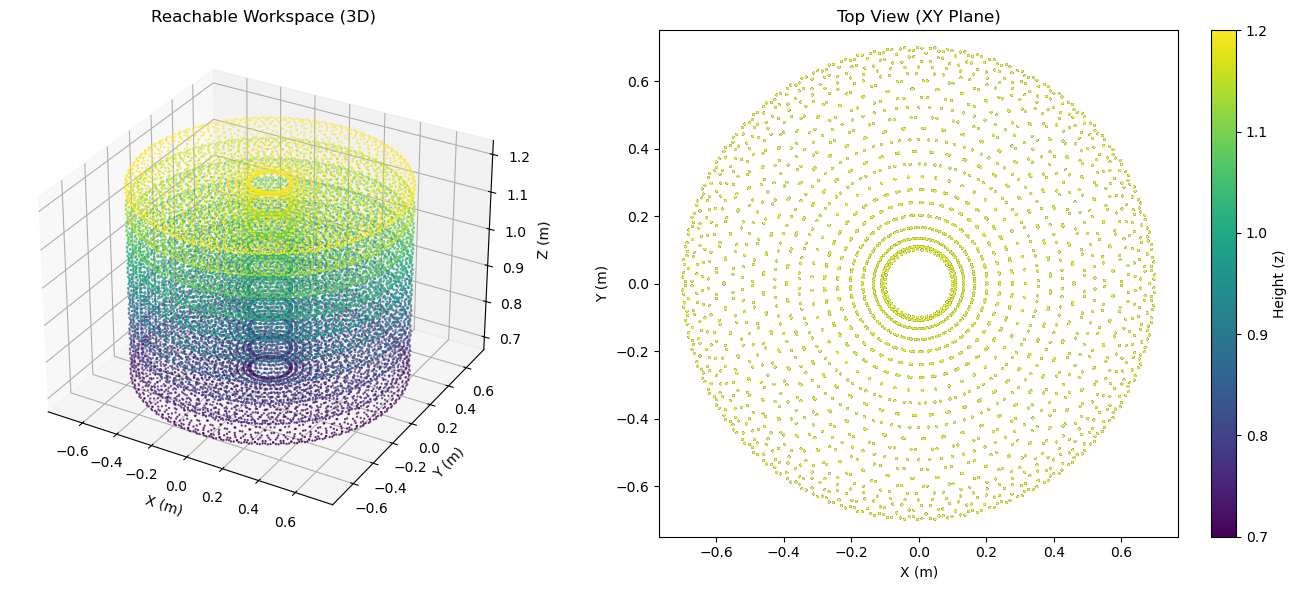

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define physical parameters
D0, L2, L3 = 0.70, 0.40, 0.30

# 2. Create grid for joint variables (Sampling)
# Using meshgrid for efficient computation instead of nested loops
n = 50  # Increased resolution for smoother visualization
q1_vals = np.linspace(0, 0.5, 10)
q2_vals = np.linspace(-np.pi, np.pi, n)
q3_vals = np.linspace(-np.pi, np.pi, n)

Q2, Q3 = np.meshgrid(q2_vals, q3_vals)

# 3. Calculate spatial coordinates for the entire grid
x_pts, y_pts, z_pts = [], [], []

for q1 in q1_vals:
    # Closed-form kinematic equations
    x = np.cos(Q2) * (L2 + L3 * np.cos(Q3)) - L3 * np.sin(Q2) * np.sin(Q3)
    y = np.sin(Q2) * (L2 + L3 * np.cos(Q3)) + L3 * np.cos(Q2) * np.sin(Q3)
    z = np.full_like(x, D0 + q1)
    
    # Flattening the arrays to append to our main list
    x_pts.extend(x.flatten())
    y_pts.extend(y.flatten())
    z_pts.extend(z.flatten())

# 4. Plotting the results
fig = plt.figure(figsize=(14, 6))

# 3D Workspace plot
ax1 = fig.add_subplot(121, projection='3d')
sc = ax1.scatter(x_pts, y_pts, z_pts, c=z_pts, cmap='viridis', s=0.5)
ax1.set_title("Reachable Workspace (3D)")
ax1.set_xlabel("X (m)")
ax1.set_ylabel("Y (m)")
ax1.set_zlabel("Z (m)")

# Top view (XY Plane) plot
ax2 = fig.add_subplot(122)
sc2 = ax2.scatter(x_pts, y_pts, c=z_pts, cmap='viridis', s=0.5)
ax2.set_title("Top View (XY Plane)")
ax2.set_xlabel("X (m)")
ax2.set_ylabel("Y (m)")
ax2.axis('equal') # Ensure aspect ratio is equal for accurate shape representation
plt.colorbar(sc2, label='Height (z)')

plt.tight_layout()
plt.show()


# B.5

In [4]:
import numpy as np

# Robot physical parameters
D0, L2, L3 = 0.70, 0.40, 0.30

# Data of detected disks from computer vision (Section A)
my_data = [
    {'color': 'red', 'xy': (0.186, -0.104)},
    {'color': 'red', 'xy': (0.103, 0.052)},
    {'color': 'green', 'xy': (-0.053, 0.209)},
    {'color': 'green', 'xy': (-0.156, 0.073)},
    {'color': 'blue', 'xy': (-0.229, -0.187)}
]

def find_best_ik(tx, ty, L2, L3):
    """Finds optimal q2 and q3 using a grid search (Brute-force)."""
    best_err = float('inf')
    best_q = (0, 0)
    
    # Sampling range for joint angles
    q2_samples = np.linspace(-np.pi, np.pi, 250)
    q3_samples = np.linspace(-np.pi, np.pi, 250)
    
    for q2 in q2_samples:
        for q3 in q3_samples:
            # Forward kinematics for the planar 2R part
            x = L2 * np.cos(q2) + L3 * np.cos(q2 + q3)
            y = L2 * np.sin(q2) + L3 * np.sin(q2 + q3)
            
            # Euclidean distance error
            dist = np.sqrt((x - tx)**2 + (y - ty)**2)
            
            if dist < best_err:
                best_err = dist
                best_q = (q2, q3)
                
    return best_q, best_err

# Execution and Result Formatting
print(f"{'Color':<8} | {'Coordinates (m)':<18} | {'Error (m)':<10} | {'Status'}")
print("-" * 55)

for disk in my_data:
    tx, ty = disk['xy']
    
    # Perform IK search
    q_sol, err = find_best_ik(tx, ty, L2, L3)
    
    # Check if error is within the 5mm threshold
    reachable = err < 0.005
    status = "Success" if reachable else "Out of Range"
    
    print(f"{disk['color']:<8} | ({tx:>6.3f}, {ty:>6.3f}) | {err:.5f}   | {status}")


Color    | Coordinates (m)    | Error (m)  | Status
-------------------------------------------------------
red      | ( 0.186, -0.104) | 0.00163   | Success
red      | ( 0.103,  0.052) | 0.00226   | Success
green    | (-0.053,  0.209) | 0.00167   | Success
green    | (-0.156,  0.073) | 0.00151   | Success
blue     | (-0.229, -0.187) | 0.00253   | Success
